In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 加载数据
mean_data = torch.load('../data/mean.pth', weights_only=False)
std_data = torch.load('../data/std.pth', weights_only=False)

print("=" * 50)
print("数据加载成功!")
print("=" * 50)

数据加载成功!


In [11]:
# 查看mean数据的类型和结构
print("【mean.pth 信息】")
print(f"  类型: {type(mean_data)}")

if isinstance(mean_data, dict):
    print(f"  键: {list(mean_data.keys())}")
    for key, value in mean_data.items():
        if isinstance(value, (torch.Tensor, np.ndarray)):
            print(f"    {key}: shape={value.shape}, dtype={value.dtype}")
        else:
            print(f"    {key}: {type(value)} = {value}")
elif isinstance(mean_data, torch.Tensor):
    print(f"  Shape: {mean_data.shape}")
    print(f"  Dtype: {mean_data.dtype}")
    print(f"  Min: {mean_data.min().item():.6f}")
    print(f"  Max: {mean_data.max().item():.6f}")
    print(f"  Mean: {mean_data.mean().item():.6f}")
# else:
    print(f"  值: {mean_data}")

【mean.pth 信息】
  类型: <class 'torch.Tensor'>
  Shape: torch.Size([1, 16, 13])
  Dtype: torch.float32
  Min: 0.000002
  Max: 0.000006
  Mean: 0.000003
  值: tensor([[[6.1888e-06, 5.0407e-06, 3.5021e-06, 2.5339e-06, 1.9819e-06,
          1.6891e-06, 1.5995e-06, 1.6951e-06, 2.0027e-06, 2.5675e-06,
          3.4562e-06, 4.9128e-06, 5.9370e-06],
         [6.1470e-06, 4.9735e-06, 3.4694e-06, 2.5256e-06, 1.9756e-06,
          1.6898e-06, 1.6081e-06, 1.7241e-06, 2.0350e-06, 2.5457e-06,
          3.4913e-06, 4.9659e-06, 6.0933e-06],
         [6.1888e-06, 6.0015e-06, 4.8933e-06, 3.4288e-06, 2.4951e-06,
          1.9524e-06, 1.6793e-06, 1.6335e-06, 1.7575e-06, 2.0189e-06,
          2.5670e-06, 3.5289e-06, 5.0572e-06],
         [5.0407e-06, 6.1470e-06, 5.7988e-06, 4.7948e-06, 3.3696e-06,
          2.4438e-06, 1.9158e-06, 1.6857e-06, 1.6358e-06, 1.7037e-06,
          1.9817e-06, 2.5286e-06, 3.5138e-06],
         [3.5021e-06, 4.9735e-06, 6.0015e-06, 5.7996e-06, 4.7665e-06,
          3.3305e-06, 2.4310e

In [12]:
# 查看std数据的类型和结构
print("【std.pth 信息】")
print(f"  类型: {type(std_data)}")

if isinstance(std_data, dict):
    print(f"  键: {list(std_data.keys())}")
    for key, value in std_data.items():
        if isinstance(value, (torch.Tensor, np.ndarray)):
            print(f"    {key}: shape={value.shape}, dtype={value.dtype}")
        else:
            print(f"    {key}: {type(value)} = {value}")
elif isinstance(std_data, torch.Tensor):
    print(f"  Shape: {std_data.shape}")
    print(f"  Dtype: {std_data.dtype}")
    print(f"  Min: {std_data.min().item():.6f}")
    print(f"  Max: {std_data.max().item():.6f}")
    print(f"  Mean: {std_data.mean().item():.6f}")
else:
    print(f"  值: {std_data}")

【std.pth 信息】
  类型: <class 'torch.Tensor'>
  Shape: torch.Size([1, 16, 13])
  Dtype: torch.float32
  Min: 0.000007
  Max: 0.000035
  Mean: 0.000015


mean shape: (16, 13)
std shape: (16, 13)


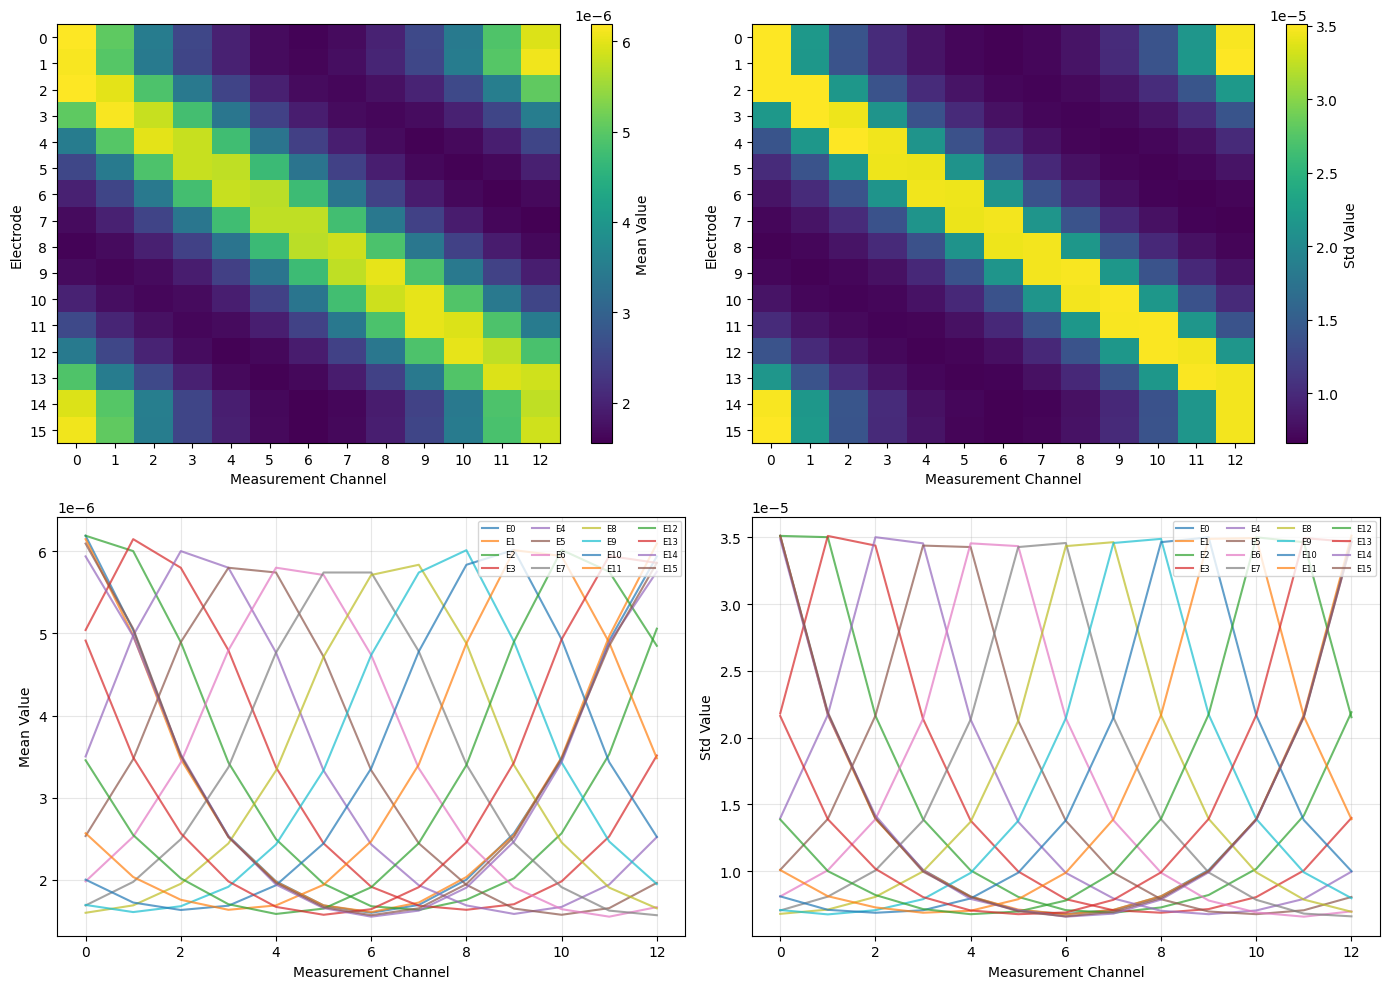

In [13]:
# 可视化mean和std数据
# 数据shape为(1, 16, 13)，对应(batch, 电极数, 测量通道数)

# 转换为numpy并去掉batch维度
mean_arr = mean_data.squeeze(0).numpy()  # (16, 13)
std_arr = std_data.squeeze(0).numpy()    # (16, 13)

print(f"mean shape: {mean_arr.shape}")
print(f"std shape: {std_arr.shape}")

# 创建可视化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean 热力图
im0 = axes[0, 0].imshow(mean_arr, cmap='viridis', aspect='auto')
axes[0, 0].set_xlabel('Measurement Channel')
axes[0, 0].set_ylabel('Electrode')
axes[0, 0].set_xticks(range(13))
axes[0, 0].set_yticks(range(16))
plt.colorbar(im0, ax=axes[0, 0], label='Mean Value')

# Std 热力图
im1 = axes[0, 1].imshow(std_arr, cmap='viridis', aspect='auto')
axes[0, 1].set_xlabel('Measurement Channel')
axes[0, 1].set_ylabel('Electrode')
axes[0, 1].set_xticks(range(13))
axes[0, 1].set_yticks(range(16))
plt.colorbar(im1, ax=axes[0, 1], label='Std Value')

# Mean 每个电极的曲线
for i in range(16):
    axes[1, 0].plot(mean_arr[i], label=f'E{i}', alpha=0.7)
axes[1, 0].set_xlabel('Measurement Channel')
axes[1, 0].set_ylabel('Mean Value')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=6, ncol=4, loc='upper right')

# Std 每个电极的曲线
for i in range(16):
    axes[1, 1].plot(std_arr[i], label=f'E{i}', alpha=0.7)
axes[1, 1].set_xlabel('Measurement Channel')
axes[1, 1].set_ylabel('Std Value')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=6, ncol=4, loc='upper right')

plt.tight_layout()
plt.show()

In [8]:
# 如果是字典，分别可视化各个键的数据
def visualize_dict_data(data_dict, prefix):
    for key, value in data_dict.items():
        if isinstance(value, (torch.Tensor, np.ndarray)):
            visualize_tensor(value, f'{prefix}["{key}"]')

if isinstance(mean_data, dict):
    visualize_dict_data(mean_data, 'mean')
    
if isinstance(std_data, dict):
    visualize_dict_data(std_data, 'std')

In [9]:
# 打印完整的原始数据内容
print("=" * 50)
print("mean.pth 完整内容:")
print("=" * 50)
print(mean_data)

print("\n" + "=" * 50)
print("std.pth 完整内容:")
print("=" * 50)
print(std_data)

mean.pth 完整内容:
tensor([[[6.1888e-06, 5.0407e-06, 3.5021e-06, 2.5339e-06, 1.9819e-06,
          1.6891e-06, 1.5995e-06, 1.6951e-06, 2.0027e-06, 2.5675e-06,
          3.4562e-06, 4.9128e-06, 5.9370e-06],
         [6.1470e-06, 4.9735e-06, 3.4694e-06, 2.5256e-06, 1.9756e-06,
          1.6898e-06, 1.6081e-06, 1.7241e-06, 2.0350e-06, 2.5457e-06,
          3.4913e-06, 4.9659e-06, 6.0933e-06],
         [6.1888e-06, 6.0015e-06, 4.8933e-06, 3.4288e-06, 2.4951e-06,
          1.9524e-06, 1.6793e-06, 1.6335e-06, 1.7575e-06, 2.0189e-06,
          2.5670e-06, 3.5289e-06, 5.0572e-06],
         [5.0407e-06, 6.1470e-06, 5.7988e-06, 4.7948e-06, 3.3696e-06,
          2.4438e-06, 1.9158e-06, 1.6857e-06, 1.6358e-06, 1.7037e-06,
          1.9817e-06, 2.5286e-06, 3.5138e-06],
         [3.5021e-06, 4.9735e-06, 6.0015e-06, 5.7996e-06, 4.7665e-06,
          3.3305e-06, 2.4310e-06, 1.9345e-06, 1.6891e-06, 1.5853e-06,
          1.6711e-06, 1.9432e-06, 2.5204e-06],
         [2.5339e-06, 3.4694e-06, 4.8933e-06, 5.79

## 数据用途说明

`mean.pth` 和 `std.pth` 通常用于数据标准化（Normalization）：

$$x_{normalized} = \frac{x - mean}{std}$$

这样可以将数据转换为零均值、单位方差的分布，有助于神经网络的训练稳定性。